## Mecánica del vuelo - Tarea N°2: Velocidad y aerodinámica
### Datos simulados

#### Actividad 1

In [3]:
with open('cessna172_actividad1.csv', 'r') as archivo:
    lineas = [line.rstrip(';') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [ft]

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(';')[0]))
    v_true.append(float(i.split(';')[2]))
    altitude.append(float(i.split(';')[9]))

In [2]:
def z(H):
    R_e = 20925524.9 # [ft]
    return R_e*H/(R_e + H)
def T(T_i,T_grad,Z,Z_i):
    return T_i+T_grad*(Z-Z_i)

def P(P_i,T,T_i,g_0,R,T_grad):
    return P_i*(T/T_i)^(-g_0/(R*T_grad))

def rho(P,R,T):
    return P/(R*T)

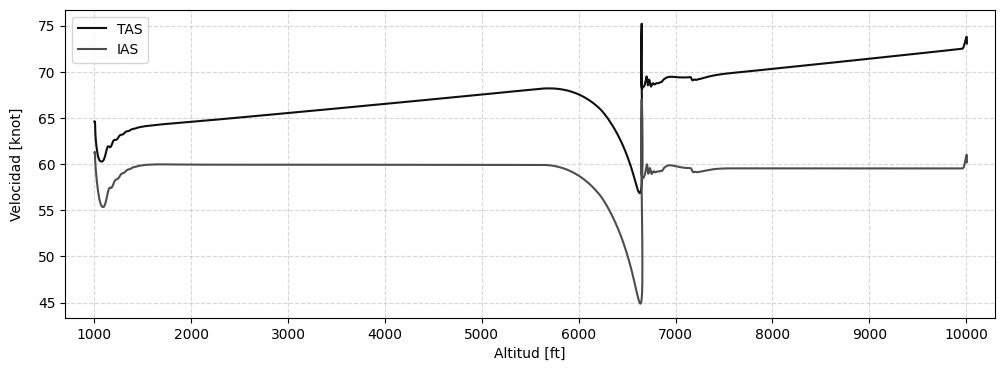

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12,4)

plt.plot(altitude[66:], v_true[66:], label='TAS',color='#0F0F0F',marker ="")
plt.plot(altitude[66:], v_indicated[66:], label='IAS',color='#4D4D4D',marker ="")
plt.xticks(range(0, 10001, 1000))
plt.xlim(700, 10300)
plt.xlabel('Altitud [ft]')
plt.ylabel('Velocidad [knot]', labelpad=10)
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#### Actividad 2
##### 2558 lb a 1000 ft

In [12]:
with open('cessna172-100kn-1000ft.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(',')[0]))
    v_true.append(float(i.split(',')[2]))
    lift.append((float(i.split(',')[20])+float(i.split(',')[22])+float(i.split(',')[24]))*4.45)
    drag.append((float(i.split(',')[26])+float(i.split(',')[28])+float(i.split(',')[30]))*4.45)
    altitude.append(float(i.split(',')[14]) * 0.3048 / 1000)
    alpha.append(float(i.split(',')[7]))

In [13]:
def cL(sust, altura):
    c_L = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(sust)):
        c_L.append(2 * sust[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_L

def cD(arr, altura):
    c_D = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(arr)):
        c_D.append(2 * arr[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_D

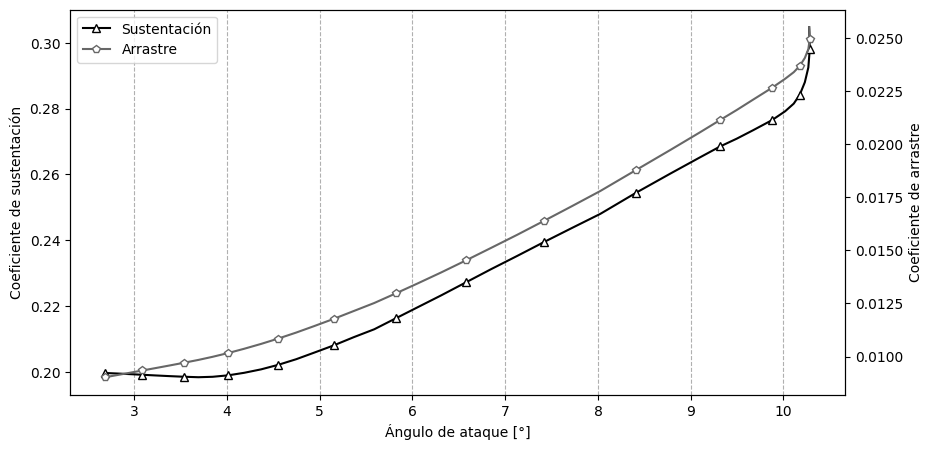

In [14]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

plotcl, = ax1.plot(alpha[28:-12], cL(lift[28:-12], 1000), color='black', marker='^', markeredgecolor='black', markerfacecolor='white', markevery=3)
ax1.set_xlabel('Ángulo de ataque [°]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2 = ax1.twinx()

plotcd, = ax2.plot(alpha[28:-12], cD(drag[28:-12], 1000), color = '#676767', marker='p', markeredgecolor='#676767', markerfacecolor='white', markevery=3)
ax2.set_ylabel('Coeficiente de arrastre')

ax1.grid(linestyle='--', axis='x')
plt.legend([plotcl, plotcd], ['Sustentación', 'Arrastre'], loc='upper left')

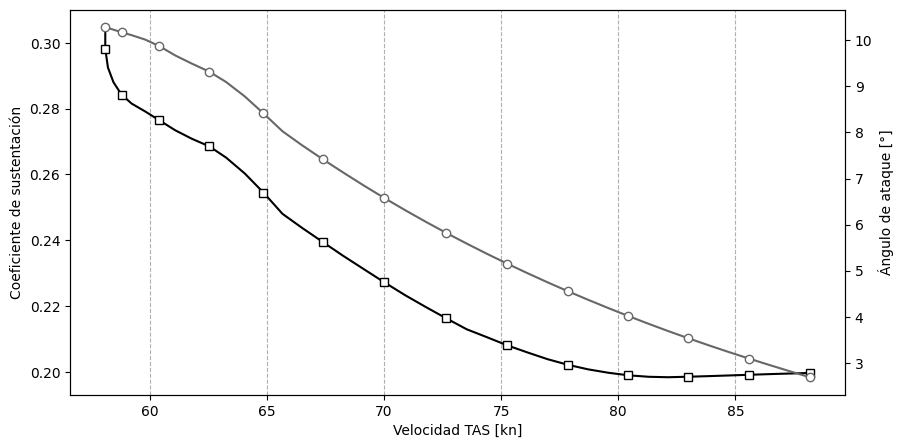

In [15]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

ax1.plot(v_true[28:-12], cL(lift[28:-12], 1000), color='black', marker='s', markeredgecolor='black', markerfacecolor='white', markevery=3)
ax1.set_xlabel('Velocidad TAS [kn]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2 = ax1.twinx()

ax2.plot(v_true[28:-12], alpha[28:-12], color="#676767", marker='o', markeredgecolor='#676767', markerfacecolor='white', markevery=3)
ax2.set_xlabel('Velocidad TAS [kn]')
ax2.set_ylabel('Ángulo de ataque [°]')

ax1.grid(linestyle='--', axis='x')

##### 1730 lb a 1000 ft

In [7]:
with open('1000ft_1730lb_2.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]

# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(';')[7]))
    v_true.append(float(i.split(';')[9]))
    lift.append(float(i.split(';')[23])+float(i.split(';')[24])+float(i.split(';')[25])+float(i.split(';')[26])+float(i.split(';')[27])+float(i.split(';')[28])*4.45)
    drag.append(float(i.split(';')[29])+float(i.split(';')[30])+float(i.split(';')[31])+float(i.split(';')[32])+float(i.split(';')[33])+float(i.split(';')[34])*4.45)
    # altitude.append(float(i.split(';')[14]) * 0.3048 / 1000)
    alpha.append(float(i.split(';')[14]))

cl_1=cL(lift, 1000)
cd_1=cD(drag, 1000)
# print(cl)

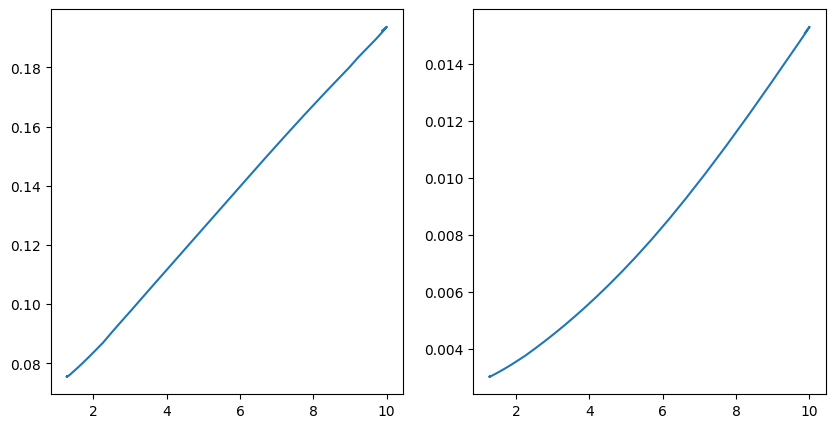

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha[100:143], cl_1[100:143])
ax2.plot(alpha[100:143], cd_1[100:143])

##### 2558 lb a 10000 ft

In [9]:
with open('10000ft_2558lb_2.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]
CL=[]
CD=[]

# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(';')[7]))
    v_true.append(float(i.split(';')[9]))
    lift.append((float(i.split(';')[23])+float(i.split(';')[24])+float(i.split(';')[25])+float(i.split(';')[26])+float(i.split(';')[27])+float(i.split(';')[28]))*4.45)
    # lift.append(float(i.split(';')[23])*4.45)
    drag.append((float(i.split(';')[29])+float(i.split(';')[30])+float(i.split(';')[31])+float(i.split(';')[32])+float(i.split(';')[33])+float(i.split(';')[34]))*4.45)
    # drag.append(float(i.split(';')[29])*4.45)
    # altitude.append(float(i.split(';')[14]) * 0.3048 / 1000)
    CL.append(float(i.split(';')[20]))
    CD.append(float(i.split(';')[21]))
    alpha.append(float(i.split(';')[14]))

cl_2=cL(lift, 10000)
cd_2=cD(drag, 10000)
# print(cl)

1.0715562099102118
0.5816231834844598


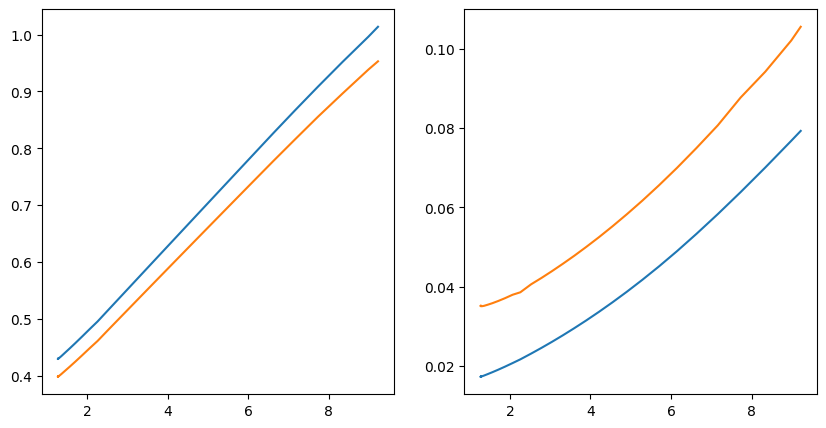

In [10]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha[100:], cl_2[100:])
ax1.plot(alpha[100:], CL[100:])
ax2.plot(alpha[100:], cd_2[100:])
ax2.plot(alpha[100:], CD[100:])
print(cl_2[120]/CL[120])
print(cd_2[120]/CD[120])
